CLASS IMBALANCE QUANTIFICATION
Legitimate transactions: 136,961
Fraud transactions: 14,151
Fraud rate: 0.0936 (9.3646%)
Imbalance ratio: 9.68:1


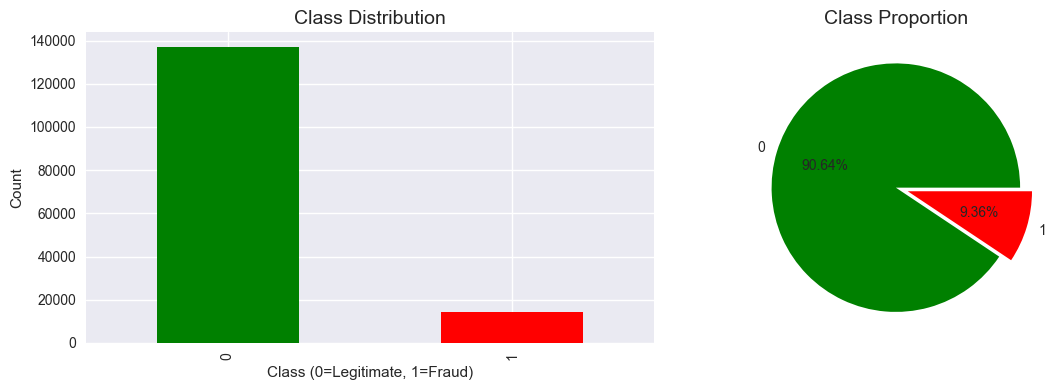


PURCHASE VALUE ANALYSIS
Mean purchase value: $36.94
Median purchase value: $35.00
Std deviation: $18.32
95th percentile: $70.00


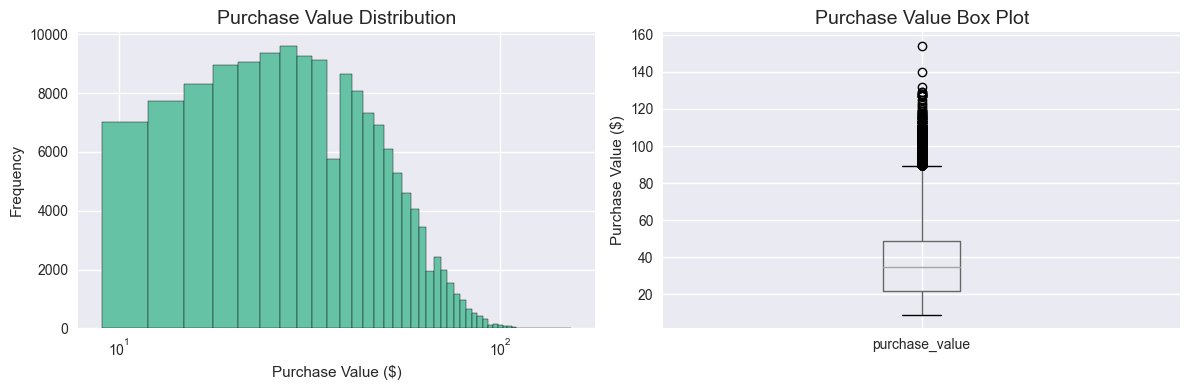


AGE ANALYSIS
Mean age: 33.1
Median age: 33.0
Age range: 18 to 76


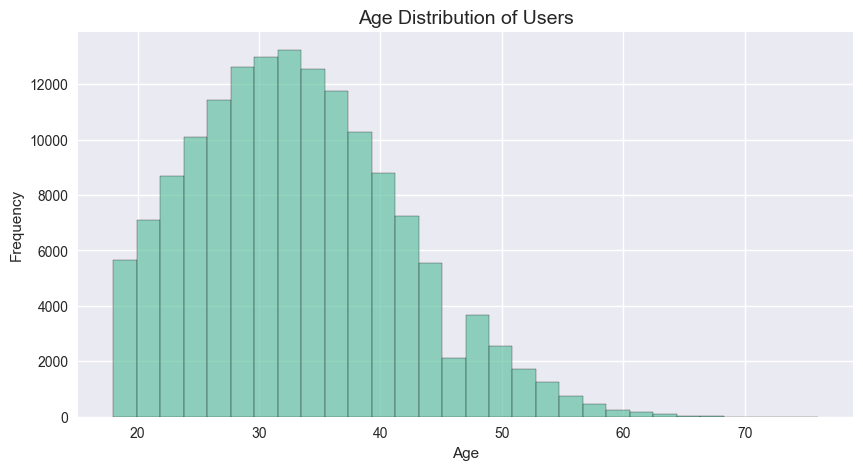


PURCHASE VALUE BY CLASS
Legitimate - Mean: $36.93, Std: $18.32
Fraud - Mean: $36.99, Std: $18.40


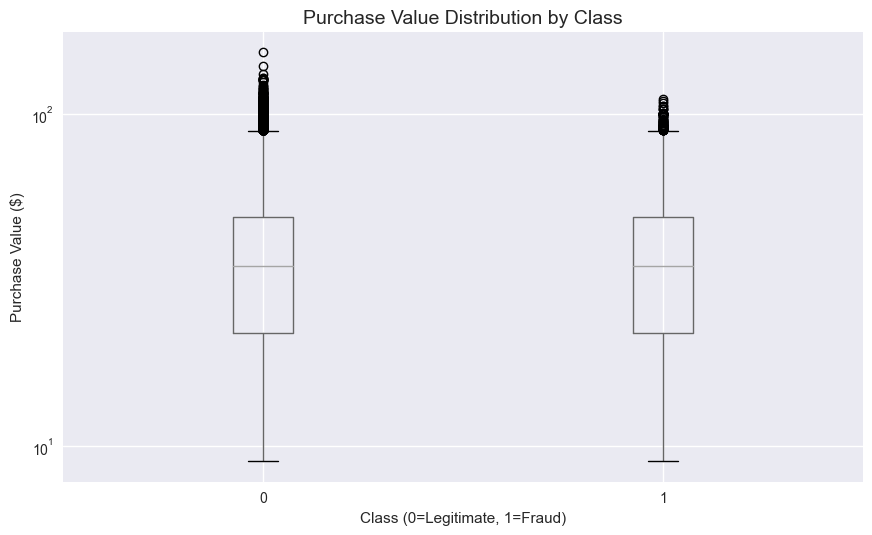


AGE BY CLASS
Legitimate - Mean age: 36.9
Fraud - Mean age: 37.0


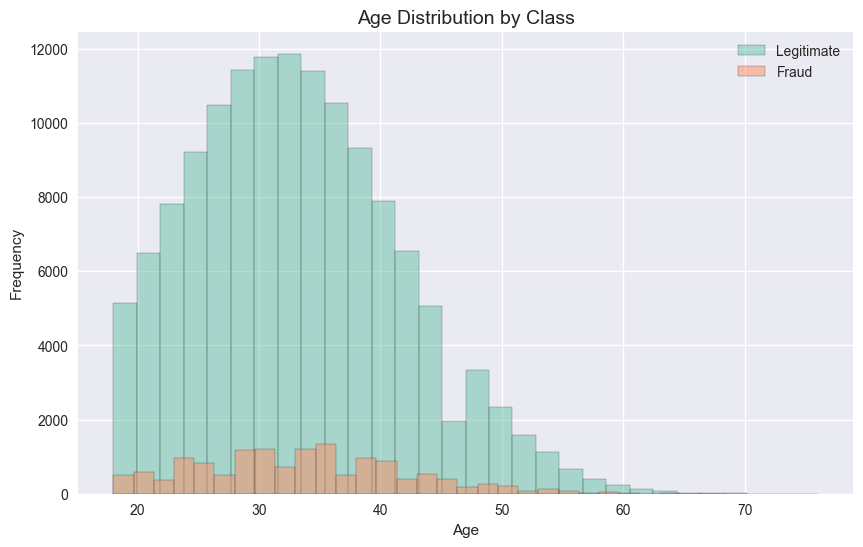


FRAUD RATE BY SOURCE CHANNEL
Direct: 10.54% fraud rate (30,616.0 transactions)
Ads: 9.21% fraud rate (59,881.0 transactions)
SEO: 8.93% fraud rate (60,615.0 transactions)


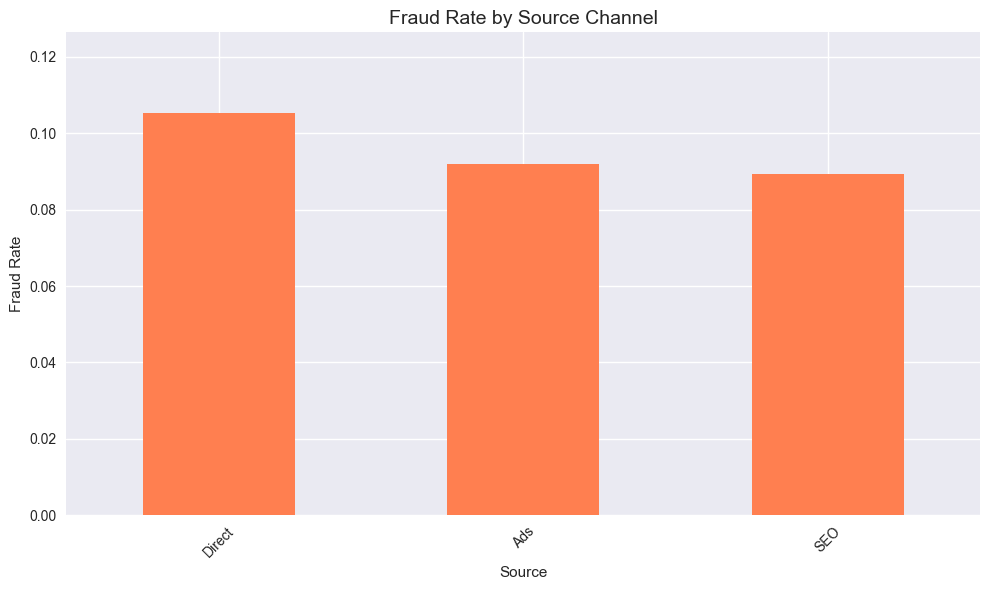


FRAUD RATE BY BROWSER
Chrome: 9.88% fraud rate (61,432.0 transactions)
FireFox: 9.52% fraud rate (24,610.0 transactions)
Safari: 9.02% fraud rate (24,667.0 transactions)
Opera: 8.92% fraud rate (3,676.0 transactions)
IE: 8.68% fraud rate (36,727.0 transactions)

CORRELATION MATRIX
                purchase_value       age     class
purchase_value        1.000000  0.002370  0.001011
age                   0.002370  1.000000  0.006624
class                 0.001011  0.006624  1.000000


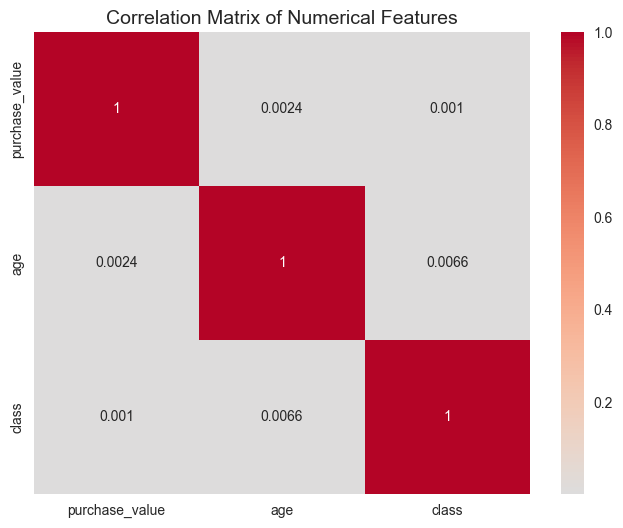


TIME-BASED FRAUD PATTERNS
Peak fraud hour: 17:00 (10.75% fraud rate)
Lowest fraud hour: 20:00 (8.18% fraud rate)


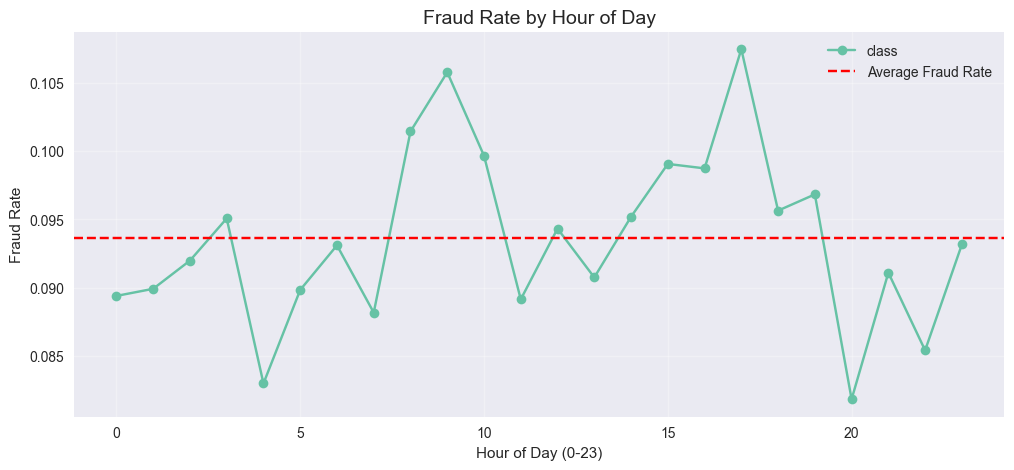

In [2]:
# Complete EDA notebook for fraud data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette('Set2')

# Load data
df = pd.read_csv('../data/raw/Fraud_Data.csv')
df['signup_time'] = pd.to_datetime(df['signup_time'])
df['purchase_time'] = pd.to_datetime(df['purchase_time'])

# ============================================
# 1. UNIVARIATE ANALYSIS
# ============================================

# 1.1 Target Variable - Class Imbalance
print("="*50)
print("CLASS IMBALANCE QUANTIFICATION")
print("="*50)
fraud_count = df['class'].sum()
legit_count = len(df) - fraud_count
fraud_rate = fraud_count / len(df)

print(f"Legitimate transactions: {legit_count:,}")
print(f"Fraud transactions: {fraud_count:,}")
print(f"Fraud rate: {fraud_rate:.4f} ({fraud_rate*100:.4f}%)")
print(f"Imbalance ratio: {legit_count/fraud_count:.2f}:1")

# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['class'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Class Distribution', fontsize=14)
axes[0].set_xlabel('Class (0=Legitimate, 1=Fraud)')
axes[0].set_ylabel('Count')
axes[0].ticklabel_format(style='plain', axis='y')

df['class'].value_counts().plot(kind='pie', autopct='%1.2f%%', ax=axes[1], 
                                 colors=['green', 'red'], explode=[0, 0.1])
axes[1].set_title('Class Proportion', fontsize=14)
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../reports/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# 1.2 Numerical Features - Purchase Value
print("\n" + "="*50)
print("PURCHASE VALUE ANALYSIS")
print("="*50)
print(f"Mean purchase value: ${df['purchase_value'].mean():.2f}")
print(f"Median purchase value: ${df['purchase_value'].median():.2f}")
print(f"Std deviation: ${df['purchase_value'].std():.2f}")
print(f"95th percentile: ${df['purchase_value'].quantile(0.95):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['purchase_value'].hist(bins=50, ax=axes[0], edgecolor='black')
axes[0].set_title('Purchase Value Distribution', fontsize=14)
axes[0].set_xlabel('Purchase Value ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_xscale('log')

df.boxplot(column='purchase_value', ax=axes[1])
axes[1].set_title('Purchase Value Box Plot', fontsize=14)
axes[1].set_ylabel('Purchase Value ($)')

plt.tight_layout()
plt.savefig('../reports/purchase_value_distribution.png', dpi=150)
plt.show()

# 1.3 Age Distribution
print("\n" + "="*50)
print("AGE ANALYSIS")
print("="*50)
print(f"Mean age: {df['age'].mean():.1f}")
print(f"Median age: {df['age'].median():.1f}")
print(f"Age range: {df['age'].min()} to {df['age'].max()}")

fig, ax = plt.subplots(figsize=(10, 5))
df['age'].hist(bins=30, edgecolor='black', alpha=0.7)
ax.set_title('Age Distribution of Users', fontsize=14)
ax.set_xlabel('Age')
ax.set_ylabel('Frequency')
plt.savefig('../reports/age_distribution.png', dpi=150)
plt.show()

# ============================================
# 2. BIVARIATE ANALYSIS
# ============================================

# 2.1 Purchase Value by Class
print("\n" + "="*50)
print("PURCHASE VALUE BY CLASS")
print("="*50)
legit_vals = df[df['class']==0]['purchase_value']
fraud_vals = df[df['class']==1]['purchase_value']
print(f"Legitimate - Mean: ${legit_vals.mean():.2f}, Std: ${legit_vals.std():.2f}")
print(f"Fraud - Mean: ${fraud_vals.mean():.2f}, Std: ${fraud_vals.std():.2f}")

fig, ax = plt.subplots(figsize=(10, 6))
df.boxplot(column='purchase_value', by='class', ax=ax)
ax.set_title('Purchase Value Distribution by Class', fontsize=14)
ax.set_xlabel('Class (0=Legitimate, 1=Fraud)')
ax.set_ylabel('Purchase Value ($)')
ax.set_yscale('log')
plt.suptitle('')
plt.savefig('../reports/purchase_value_by_class.png', dpi=150)
plt.show()

# 2.2 Age by Class
print("\n" + "="*50)
print("AGE BY CLASS")
print("="*50)
print(f"Legitimate - Mean age: {legit_vals.mean():.1f}")
print(f"Fraud - Mean age: {fraud_vals.mean():.1f}")

fig, ax = plt.subplots(figsize=(10, 6))
df[df['class']==0]['age'].hist(alpha=0.5, label='Legitimate', bins=30, edgecolor='black')
df[df['class']==1]['age'].hist(alpha=0.5, label='Fraud', bins=30, edgecolor='black')
ax.set_title('Age Distribution by Class', fontsize=14)
ax.set_xlabel('Age')
ax.set_ylabel('Frequency')
ax.legend()
plt.savefig('../reports/age_by_class.png', dpi=150)
plt.show()

# 2.3 Fraud Rate by Source
print("\n" + "="*50)
print("FRAUD RATE BY SOURCE CHANNEL")
print("="*50)
source_fraud = df.groupby('source')['class'].agg(['count', 'mean']).sort_values('mean', ascending=False)
for source, row in source_fraud.iterrows():
    print(f"{source}: {row['mean']*100:.2f}% fraud rate ({row['count']:,} transactions)")

fig, ax = plt.subplots(figsize=(10, 6))
source_fraud['mean'].plot(kind='bar', ax=ax, color='coral')
ax.set_title('Fraud Rate by Source Channel', fontsize=14)
ax.set_xlabel('Source')
ax.set_ylabel('Fraud Rate')
ax.set_ylim(0, source_fraud['mean'].max() * 1.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/fraud_by_source.png', dpi=150)
plt.show()

# 2.4 Fraud Rate by Browser
print("\n" + "="*50)
print("FRAUD RATE BY BROWSER")
print("="*50)
browser_fraud = df.groupby('browser')['class'].agg(['count', 'mean']).sort_values('mean', ascending=False)
for browser, row in browser_fraud.head(10).iterrows():
    print(f"{browser}: {row['mean']*100:.2f}% fraud rate ({row['count']:,} transactions)")

# 2.5 Correlation Matrix
print("\n" + "="*50)
print("CORRELATION MATRIX")
print("="*50)
numeric_cols = ['purchase_value', 'age', 'class']
corr_matrix = df[numeric_cols].corr()
print(corr_matrix)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix of Numerical Features', fontsize=14)
plt.savefig('../reports/correlation_matrix.png', dpi=150)
plt.show()

# ============================================
# 3. TIME-BASED ANALYSIS
# ============================================

# Extract time features
df['purchase_hour'] = df['purchase_time'].dt.hour
df['purchase_dow'] = df['purchase_time'].dt.dayofweek

print("\n" + "="*50)
print("TIME-BASED FRAUD PATTERNS")
print("="*50)

# Fraud rate by hour
hour_fraud = df.groupby('purchase_hour')['class'].mean()
peak_hour = hour_fraud.idxmax()
print(f"Peak fraud hour: {peak_hour}:00 ({hour_fraud.max()*100:.2f}% fraud rate)")
print(f"Lowest fraud hour: {hour_fraud.idxmin()}:00 ({hour_fraud.min()*100:.2f}% fraud rate)")

fig, ax = plt.subplots(figsize=(12, 5))
hour_fraud.plot(kind='line', marker='o', ax=ax)
ax.set_title('Fraud Rate by Hour of Day', fontsize=14)
ax.set_xlabel('Hour of Day (0-23)')
ax.set_ylabel('Fraud Rate')
ax.axhline(y=df['class'].mean(), color='red', linestyle='--', label='Average Fraud Rate')
ax.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../reports/fraud_by_hour.png', dpi=150)
plt.show()